In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import roc_auc_score, roc_curve


In [5]:
x_train = pd.read_csv("../data/X_train.csv")
x_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

xgb_model = joblib.load("../models/xgboost_model.pkl")
rf_model  = joblib.load("../models/random_forest_model.pkl")

print(f"x_train: {x_train.shape}")
print(f"x_test : {x_test.shape}")


x_train: (179048, 21)
x_test : (24053, 21)


In [6]:

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

for feat, score in xgb_importance.items():
    bar = "█" * int(score * 100)
    print(f"{feat:<40} {score:.4f} {bar}")

CreditUtilCategory_Medium                0.2729 ███████████████████████████
CreditUtilCategory_Very High             0.1768 █████████████████
CreditUtilCategory_High                  0.1440 ██████████████
AgeGroup_Young                           0.0773 ███████
AgeGroup_Elderly                         0.0754 ███████
RevolvingUtilizationOfUnsecuredLines     0.0548 █████
AgeGroup_Middle                          0.0441 ████
AgeGroup_Senior                          0.0404 ████
TotalTimesLate                           0.0342 ███
NumberOfTimes90DaysLate                  0.0145 █
NumberOfTime60-89DaysPastDueNotWorse     0.0144 █
age                                      0.0120 █
NumberOfTime30-59DaysPastDueNotWorse     0.0103 █
NumberRealEstateLoansOrLines             0.0058 
NumberOfDependents                       0.0046 
DebtRatio                                0.0036 
MonthlyDebt                              0.0035 
MonthlyIncome                            0.0032 
IncomePerDependent        

In [8]:

threshold = 0.01 

low_importance = xgb_importance[xgb_importance < threshold]
high_importance = xgb_importance[xgb_importance >= threshold]

print(f"Total features     : {len(xgb_importance)}")
print(f"Important features : {len(high_importance)}")
print(f"Low importance     : {len(low_importance)}")

print(f"\nFeatures to KEEP (score >= {threshold}):")
for feat, score in high_importance.items():
    print(f"   {feat:<40} {score:.4f}")

print(f"\nFeatures to REMOVE (score < {threshold}):")
for feat, score in low_importance.items():
    print(f"   {feat:<40} {score:.4f}")

Total features     : 21
Important features : 13
Low importance     : 8

Features to KEEP (score >= 0.01):
   CreditUtilCategory_Medium                0.2729
   CreditUtilCategory_Very High             0.1768
   CreditUtilCategory_High                  0.1440
   AgeGroup_Young                           0.0773
   AgeGroup_Elderly                         0.0754
   RevolvingUtilizationOfUnsecuredLines     0.0548
   AgeGroup_Middle                          0.0441
   AgeGroup_Senior                          0.0404
   TotalTimesLate                           0.0342
   NumberOfTimes90DaysLate                  0.0145
   NumberOfTime60-89DaysPastDueNotWorse     0.0144
   age                                      0.0120
   NumberOfTime30-59DaysPastDueNotWorse     0.0103

Features to REMOVE (score < 0.01):
   NumberRealEstateLoansOrLines             0.0058
   NumberOfDependents                       0.0046
   DebtRatio                                0.0036
   MonthlyDebt                            

In [22]:

selector = SelectFromModel(
    xgb_model,
    threshold=0.005,  
    prefit=True        
)
x_train_selected = selector.transform(x_train)
x_test_selected  = selector.transform(x_test)

selected_features = x_train.columns[selector.get_support()].tolist()
removed_features  = x_train.columns[~selector.get_support()].tolist()

print(f"Features before selection: {x_train.shape[1]}")
print(f"Features after selection : {x_train_selected.shape[1]}")
print(f"\nSelected features ({len(selected_features)}):")
for f in selected_features:
    print(f"   {f}")
print(f"\nRemoved features ({len(removed_features)}):")
for f in removed_features:
    print(f"   {f}")

Features before selection: 21
Features after selection : 14

Selected features (14):
   RevolvingUtilizationOfUnsecuredLines
   age
   NumberOfTime30-59DaysPastDueNotWorse
   NumberOfTimes90DaysLate
   NumberRealEstateLoansOrLines
   NumberOfTime60-89DaysPastDueNotWorse
   TotalTimesLate
   AgeGroup_Young
   AgeGroup_Middle
   AgeGroup_Senior
   AgeGroup_Elderly
   CreditUtilCategory_Medium
   CreditUtilCategory_High
   CreditUtilCategory_Very High

Removed features (7):
   DebtRatio
   MonthlyIncome
   NumberOfOpenCreditLinesAndLoans
   NumberOfDependents
   MonthlyDebt
   IncomePerDependent
   HighRiskFlag


In [23]:


xgb_selected = XGBClassifier(
    **xgb_model.get_params(), 
    
)

xgb_selected.fit(x_train_selected, y_train)


y_prob_selected = xgb_selected.predict_proba(x_test_selected)[:, 1]
auc_selected    = roc_auc_score(y_test, y_prob_selected)
y_prob_original = xgb_model.predict_proba(x_test)[:, 1]
auc_original    = roc_auc_score(y_test, y_prob_original)

print(f"\nResults comparison:")
print(f"  XGBoost (all {x_train.shape[1]} features)      : ROC-AUC = {auc_original:.4f}")
print(f"  XGBoost ({x_train_selected.shape[1]} selected features) : ROC-AUC = {auc_selected:.4f}")
diff = auc_selected - auc_original
print(f"  Difference: {diff:+.4f}")
if diff >= 0:
    print(f"   Feature selection improved or maintained performance!")
else:
    print(f"   Slight drop — but fewer features = simpler model")


Results comparison:
  XGBoost (all 21 features)      : ROC-AUC = 0.8154
  XGBoost (14 selected features) : ROC-AUC = 0.8069
  Difference: -0.0085
   Slight drop — but fewer features = simpler model


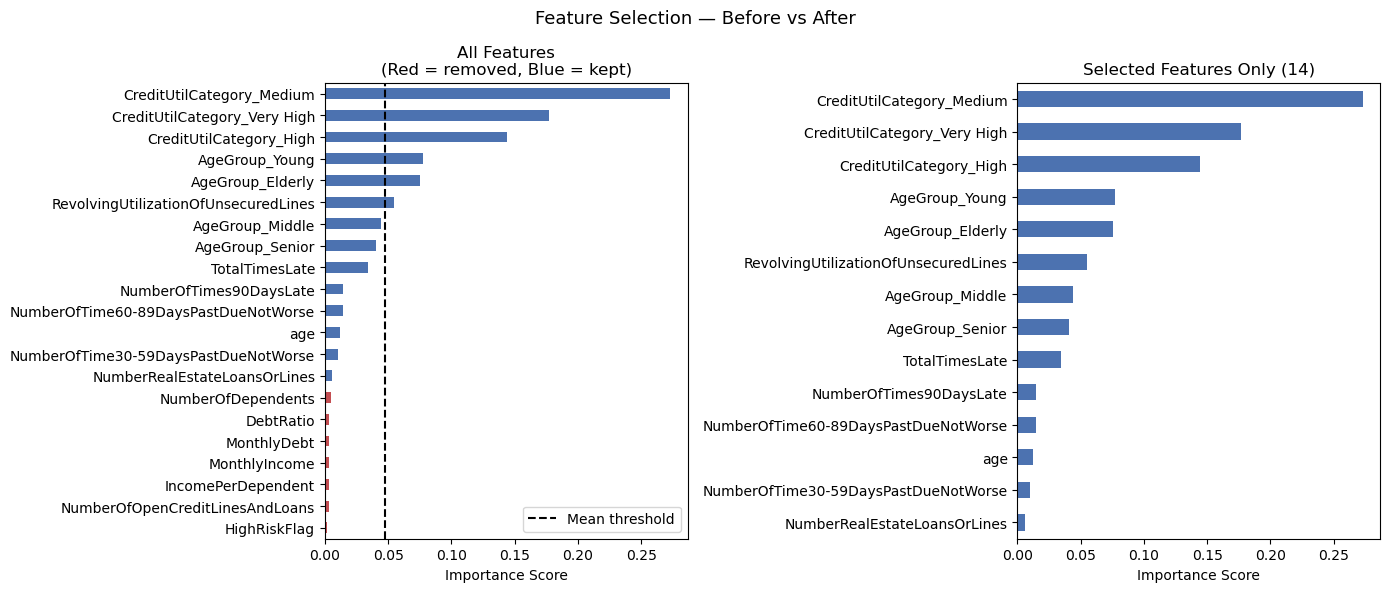

Chart saved!


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All features importance
xgb_importance.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color=["#C44E52" if f in removed_features
           else "#4C72B0" for f in xgb_importance.sort_values().index]
)
axes[0].set_title("All Features\n(Red = removed, Blue = kept)")
axes[0].set_xlabel("Importance Score")
axes[0].axvline(x=xgb_importance.mean(), color="black",
                linestyle="--", label="Mean threshold")
axes[0].legend()

# Selected features only
xgb_importance[selected_features].sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#4C72B0"
)
axes[1].set_title(f"Selected Features Only ({len(selected_features)})")
axes[1].set_xlabel("Importance Score")

plt.suptitle("Feature Selection — Before vs After", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/day10_feature_selection.png", dpi=150)
plt.show()
print("Chart saved!")

In [25]:

x_train_final = pd.DataFrame(x_train_selected, columns=selected_features)
x_test_final  = pd.DataFrame(x_test_selected,  columns=selected_features)


x_train_final.to_csv("../data/X_train_selected.csv", index=False)
x_test_final.to_csv("../data/X_test_selected.csv",   index=False)

print(f"Saved selected feature datasets:")
print(f"  data/X_train_selected.csv — {x_train_final.shape}")
print(f"  data/X_test_selected.csv  — {x_test_final.shape}")

Saved selected feature datasets:
  data/X_train_selected.csv — (179048, 14)
  data/X_test_selected.csv  — (24053, 14)


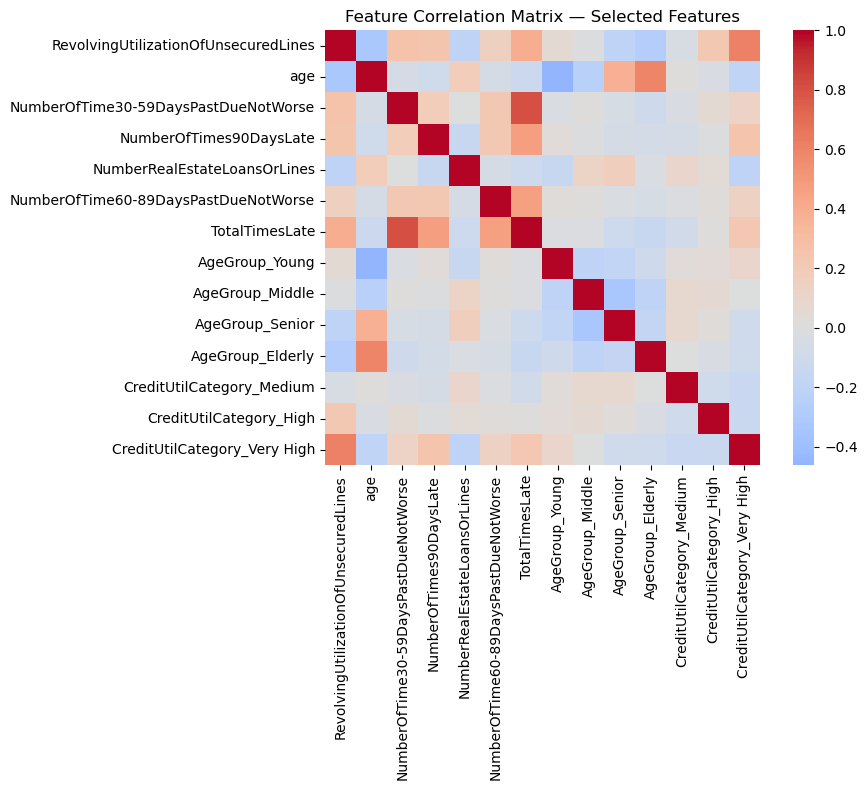


Highly correlated feature pairs (>0.8):
  NumberOfTime30-59DaysPastDueNotWorse ↔ TotalTimesLate: 0.809


In [26]:

corr_matrix = x_train_final.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Feature Correlation Matrix — Selected Features")
plt.tight_layout()
plt.savefig("../outputs/day10_correlation_matrix.png", dpi=150)
plt.show()

print("\nHighly correlated feature pairs (>0.8):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"  {corr_matrix.columns[i]} ↔ "
                  f"{corr_matrix.columns[j]}: "
                  f"{corr_matrix.iloc[i,j]:.3f}")
            found = True
if not found:
    print("  No highly correlated pairs found ✅")

In [27]:

joblib.dump(xgb_selected, "../models/xgboost_selected_features.pkl")


print(f"\nOriginal features  : {x_train.shape[1]}")
print(f"Selected features  : {len(selected_features)}")
print(f"Removed features   : {len(removed_features)}")
print(f"\nROC-AUC comparison:")
print(f"  All features     : {auc_original:.4f}")
print(f"  Selected features: {auc_selected:.4f}")
print(f"\nSelected features list:")
for f in selected_features:
    print(f"  - {f}")



Original features  : 21
Selected features  : 14
Removed features   : 7

ROC-AUC comparison:
  All features     : 0.8154
  Selected features: 0.8069

Selected features list:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - TotalTimesLate
  - AgeGroup_Young
  - AgeGroup_Middle
  - AgeGroup_Senior
  - AgeGroup_Elderly
  - CreditUtilCategory_Medium
  - CreditUtilCategory_High
  - CreditUtilCategory_Very High
